In [4]:
import quimb.tensor as qtn
import quimb as qu
import cotengra as ctg
import numpy as np


In [3]:
seed = 10

data = np.load('../../qubo_solvers/out/tangle/qubo_data_test.npy', allow_pickle=True)
Q, offset, W = data
# Move terms to upper triangular part
Q = np.triu(Q) * 2
Q -= np.triu(np.triu(Q).T) / 2
N = Q.shape[0]


def Q_to_Ising(Q, offset):
    n_qubits = Q.shape[0]
    J = {(i, i) : 0 for i in range(n_qubits)}

    for i in range(n_qubits):
        # Update the magnetic field for qubit i based on its diagonal element in Q
        J[(i, i)] -= Q[i, i] / 2
        # Update the offset based on the diagonal element in Q
        offset += Q[i, i] / 2
        # Calculate pairwise interactions
        for j in range(i + 1, n_qubits):
            # Update the pairwise interaction strength (J) between qubits i and j
            J[(i, j)] = Q[i, j] / 4
            # Update the magnetic fields for qubits i and j based on their interactions in Q
            J[(i, i)] -= Q[i, j] / 4
            J[(j, j)] -= Q[i, j] / 4
            # Update the offset based on the interaction strength between qubits i and j
            offset += Q[i, j] / 4
    del_keys = []
    for key in J.keys():
        if J[key] == 0:
            del_keys.append(key)
    for key in del_keys:
        J.pop(key)
    return J, offset


terms, offset = Q_to_Ising(Q, 0)

p = 2
gammas = qu.randn(p, seed=seed)
betas = qu.randn(p, seed=seed)

circ = qtn.Circuit(N)

for i in range(N):
    circ.apply_gate('H', i, gate_round=0)

for r in range(p):
    for (i, j), weight in terms.items():
        if i == j:
            circ.apply_gate('RZ', weight * gammas[r], i, gate_round=2*r+1, contract=False)
        else:
            circ.apply_gate('RZZ', weight * gammas[r], i, j, gate_round=2*r+1)
    for i in range(N):
        circ.apply_gate('RX', -betas[r], i, gate_round=2*r+2)



In [5]:
two_body_terms = {(i, j) : weight for (i, j), weight in list(terms.items()) if not i == j}
one_body_terms = {i : weight for (i, j), weight in list(terms.items()) if i == j}
Z = qu.pauli('Z')
ZZ = qu.pauli('Z') & qu.pauli('Z')
# TODO: better shape handling
rows = int(Q.shape[0] ** 0.5)
cols = int(Q.shape[0] ** 0.5)

ham = qtn.tensor_2d_tebd.LocalHam2D(
    rows, 
    cols,
    {
        (np.unravel_index(i, (rows, cols)), np.unravel_index(j, (rows, cols))) : weight * ZZ for (i, j), weight in list(two_body_terms.items())
    },
    {
        np.unravel_index(i, (rows, cols)) : weight * Z for i, weight in list(one_body_terms.items())
    }
)

In [1]:
W = [17.0, 14.0, 16.0, 17.0, 17.0, 15.0, 14.0, 15.0, 14.0, 18.0, 17.0, 15.0, 14.0, 14.0, 19.0, 16.0, 18.0, 15.0, 15.0, 15.0, 14.0, 13.0, 15.0, 19.0, 16.0, 17.0, 13.0, 16.0, 14.0, 15.0, 16.0, 14.0, 15.0, 15.0, 14.0, 17.0, 16.0, 14.0, 18.0, 16.0, 15.0, 16.0, 14.0, 14.0, 19.0, 17.0, 16.0, 17.0, 20.0, 16.0, 16.0, 15.0, 15.0, 15.0, 13.0, 14.0, 14.0, 14.0, 18.0, 16.0, 17.0, 15.0, 16.0, 15.0, 15.0, 15.0, 15.0, 16.0, 18.0, 14.0, 19.0, 18.0, 17.0, 16.0, 17.0, 14.0, 15.0, 14.0, 16.0, 16.0, 14.0]
C = [6.375481446369399, 5.859046983738067, 6.253537657336576, 6.433755117251088, 6.668955903482098, 6.183564778977271, 5.806806534452552, 5.989245081442606, 5.726564216162244, 6.535124420826551, 6.8495402868671675, 5.620227694979486, 5.618336832702101, 5.708662202230868, 7.040419565729297, 6.296907274852309, 6.665746047831636, 6.084151426702002, 5.78819100479147, 6.013647713186506, 5.7840606968782025, 5.813290027230613, 5.986538854178797, 7.014497353365928, 6.082074124531582, 6.468715881140244, 5.712201709668449, 6.145543205794452, 5.884437362310619, 6.05509380589122, 6.110959881124877, 5.683443308790247, 5.819630785753517, 6.193402903062417, 5.868411655296037, 6.548600187158589, 6.084036917571696, 5.873999128988327, 6.712509290715423, 6.104455698940287, 5.904553262976773, 6.295200158560941, 5.758275874004724, 5.775150063060997, 7.344886027439245, 6.300922277274836, 6.316343636276508, 6.3780503263142165, 6.887792108058116, 6.244864691065619, 6.589269828565788, 6.162958497757705, 6.042427441212476, 6.0411178082248895, 5.441097864716268, 5.675466710645693, 5.846673529087862, 5.858924401150413, 6.541894118069913, 6.383013514389229, 6.423267506179786, 5.809239093719682, 6.165431896080691, 5.807613491634508, 6.1207739238209316, 6.080262739253886, 6.074551688915577, 6.293246727405277, 7.119378636023718, 5.654526917557813, 7.313913598856762, 6.880076037183423, 6.543658373535019, 6.158355253793565, 6.373521060157015, 5.8225734060954855, 5.876937987222106, 6.026175222368867, 5.8933644477421625, 6.414368255087382, 5.795551914244011]

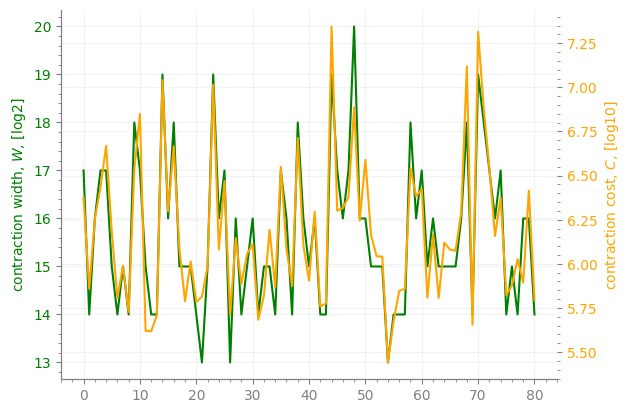

In [5]:
import matplotlib.pyplot as plt

with plt.style.context(qu.NEUTRAL_STYLE):
    fig, ax1 = plt.subplots()
    ax1.plot(W, color='green')
    ax1.set_ylabel('contraction width, $W$, [log2]', color='green')
    ax1.tick_params(axis='y', labelcolor='green')

    ax2 = ax1.twinx()
    ax2.plot(C, color='orange')
    ax2.set_ylabel('contraction cost, $C$, [log10]', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')